In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

# Load dataset
df = pd.read_csv('loan_approval - loan_approval.csv')

# Preprocessing
X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

print("Setup Complete ✅")

Setup Complete ✅


###Q1. Data Loading & Understanding
Question:

a) Load the dataset

b) Display first 5 rows

c) Check shape

d) Display data types

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 Load dataset
df = pd.read_csv('loan_approval - loan_approval.csv')

# 🔹 Display first 5 rows
print("First 5 Rows:\n", df.head())

# 🔹 Shape of dataset
print("\nShape of Dataset:", df.shape)

# 🔹 Data types
print("\nData Types:\n", df.dtypes)

First 5 Rows:
               name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27      50          False  
1              28      55          False  
2              13      45          False  
3              29      50          False  
4               4      25          False  

Shape of Dataset: (2000, 8)

Data Types:
 name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


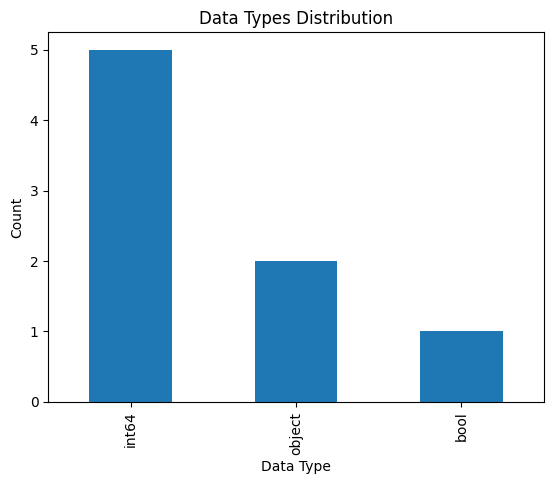

In [93]:
# Count data types
df.dtypes.value_counts().plot(kind='bar')

plt.title("Data Types Distribution")
plt.xlabel("Data Type")
plt.ylabel("Count")

plt.show()

###Visualization Explanation

The bar chart shows the distribution of different data types present in the dataset.

It helps in understanding how many features are numerical and how many are categorical.

### Output Explanation
####First 5 rows:
Displays a sample of the dataset to understand structure and values
####Shape:
Shows total number of rows and columns

Example: (1000, 7) → 1000 records, 7 features
####Data Types:
int/float → numerical data

object → categorical data

Visualization Insight:

Helps identify how many variables need encoding or preprocessing
###Final Conclusion

Data loading and understanding is the first step in any machine learning project. The dataset was successfully loaded, and its structure, size, and data types were analyzed. This helps in planning further steps such as data cleaning and preprocessing.

###Q2. Data Cleaning
Question:

###a) Check missing values



In [67]:
df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


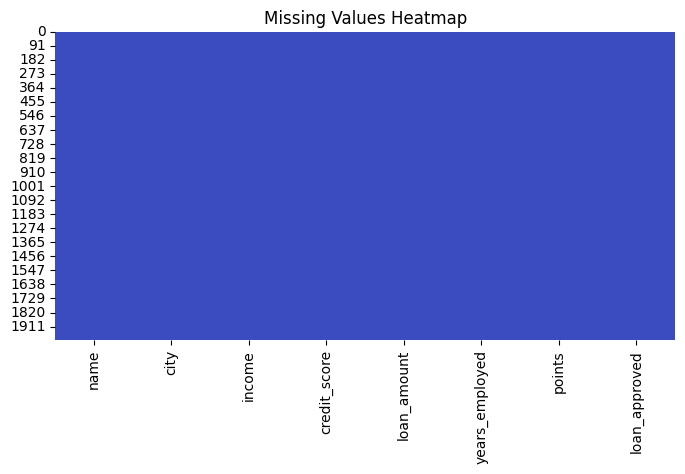

In [68]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='coolwarm')
plt.title("Missing Values Heatmap")
plt.show()

###Visualization Explanation

The heatmap is used to visually identify missing values in the dataset.
Each column represents a feature and each row represents an observation.
Colored cells indicate missing values, while blank cells indicate available data.

###Output Explanation
The output shows the count of missing values in each column.
In this dataset, all values are 0, which means there are no missing values present.
The heatmap also confirms this, as it appears mostly blank without any highlighted areas.

###(b) Handle Missing Values

In [69]:
# Fill numeric values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical values using forward fill
df.ffill(inplace=True)

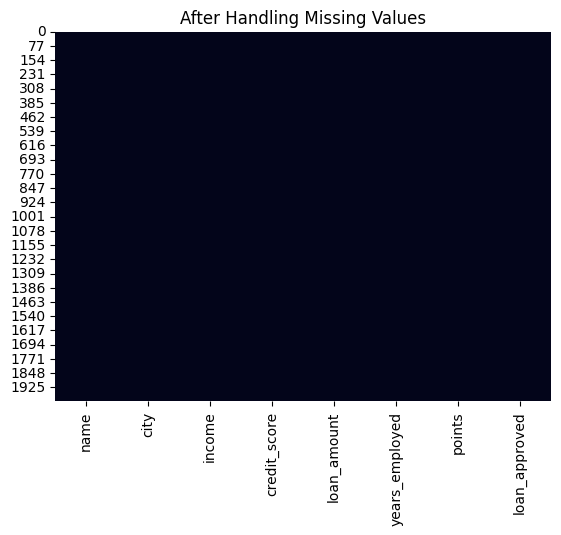

In [70]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("After Handling Missing Values")
plt.show()

###Visualization Explanation

The heatmap after handling missing values is used to confirm that all missing values have been properly treated.
If the dataset is clean, the heatmap will not show any highlighted or colored cells.

###Output Explanation
After applying mean and forward fill methods, all missing values are handled.
The dataset becomes complete and ready for further analysis.
Even though the dataset initially had no missing values, this step ensures robustness.

###(c) Identify Categorical Columns

In [71]:
df.select_dtypes(include='object').columns

Index(['name', 'city'], dtype='object')

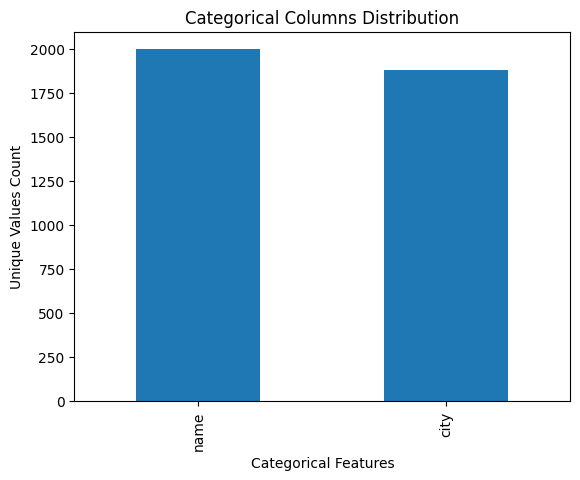

In [72]:
df.select_dtypes(include='object').nunique().plot(kind='bar')
plt.title("Categorical Columns Distribution")
plt.xlabel("Categorical Features")
plt.ylabel("Unique Values Count")
plt.show()

###Visualization Explanation

The bar chart shows the number of unique values in each categorical column.
It helps in understanding how many categories exist within each feature.

###Output Explanation
The output lists categorical columns such as name and city.
These columns contain text data and need to be converted into numeric format later.
The visualization shows how many unique categories each column contains, which helps in deciding encoding techniques.
###Final Conclusion

Data cleaning is an essential step in machine learning. Missing values were checked and handled appropriately, and categorical variables were identified for further preprocessing. This ensures that the dataset is clean, structured, and ready for analysis and model building.

###Q3. Exploratory Data Analysis (EDA)
Question:

###a) Plot the distribution of the target variable
###b) Analyze relationship between one numerical feature and target
###c) Analyze relationship between Years of Employment and target

###(a) Target Variable Distribution

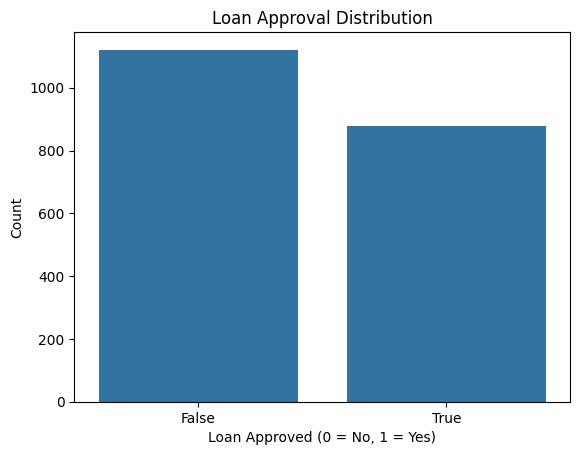

In [73]:
sns.countplot(x='loan_approved', data=df)
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

###Visualization Explanation:

The countplot is used to visualize the frequency distribution of the target variable loan_approved. It displays the number of loan applications that were approved (1) and not approved (0).

The X-axis represents the target variable (loan approval status).
The Y-axis represents the count (number of applicants).
Each bar shows how many applicants fall into each category.

This visualization helps in understanding the class distribution of the dataset before building a machine learning model.

###Output Interpretation:

From the graph, we can observe whether the dataset is balanced or imbalanced:

If the number of approved loans (1) is significantly higher than rejected loans (0), the dataset is imbalanced.
If both categories are almost equal, the dataset is balanced.

An imbalanced dataset can lead to a biased model that predicts the majority class more often.

###Conclusion:

The distribution of the target variable indicates whether there is class imbalance in the dataset, which is an important factor affecting model performance and prediction accuracy.

##(b) Relationship Between Income and Loan Approval

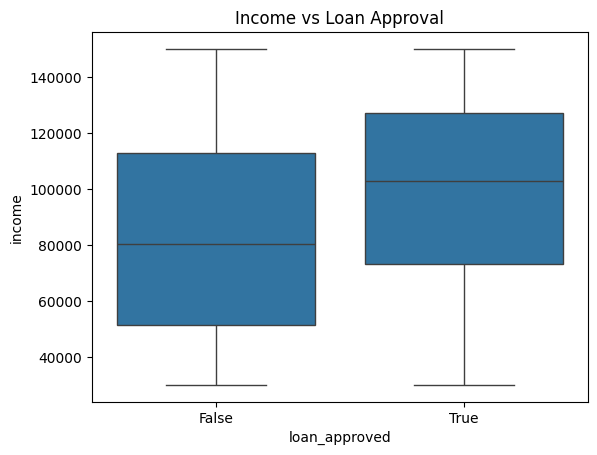

In [74]:
sns.boxplot(x='loan_approved', y='income', data=df)
plt.title("Income vs Loan Approval")
plt.show()

###Visualization Explanation:

A boxplot is used to compare the distribution of a numerical variable (income) across different categories of the target variable (loan_approved).

###The boxplot shows:

Median (center line) → typical income value
Interquartile Range (box) → spread of the middle 50% data
Whiskers → range of data
Outliers (dots) → extreme income values

This visualization helps in identifying how income varies between approved and rejected loan applicants.

###Output Interpretation

From the boxplot, we can analyze:

If the median income for approved loans (1) is higher than rejected loans (0), it indicates that higher income increases the probability of loan approval.
If rejected applicants show lower income levels, it suggests financial instability as a possible reason for rejection.
Presence of outliers indicates that some applicants have unusually high or low income values.

###Conclusion:

The analysis shows that applicants with higher income are more likely to have their loans approved. Income is therefore a significant factor influencing loan approval decisions.

##(c) Relationship Between Years of Employment and Loan Approval

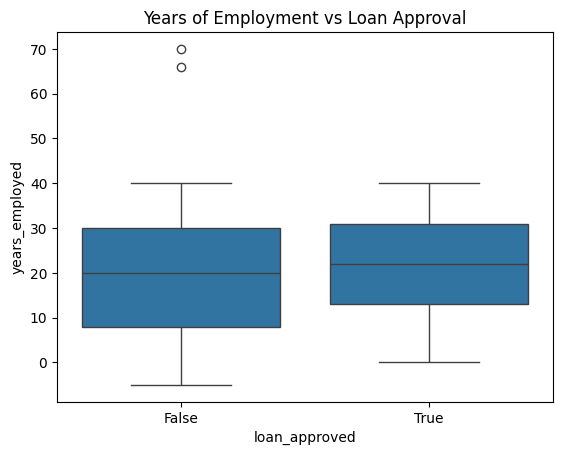

In [75]:
sns.boxplot(x='loan_approved', y='years_employed', data=df)
plt.title("Years of Employment vs Loan Approval")
plt.show()

###Visualization Explanation (Expanded)
This boxplot compares the number of years an applicant has been employed (years_employed) with their loan approval status.


It shows the distribution of employment duration for approved and rejected applicants.


It highlights whether job stability plays a role in loan approval decisions.



###Output Interpretation :
From the graph, we can observe:


Applicants with more years of employment tend to have higher approval rates.


Longer employment duration indicates job stability and financial reliability, which reduces risk for lenders.


Applicants with fewer years of employment are more likely to be rejected due to uncertainty in income stability.


###Conclusion:

The visualization indicates that years of employment is an important factor in loan approval, as individuals with stable and long-term employment are more likely to be approved.





###Q4. Outlier Detection and Treatment
Question:

###a) Detect outliers in numerical columns using the IQR method
###b) Treat outliers using capping techniques

##(a) Outlier Detection using IQR Method

In [76]:
import numpy as np

# Select numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# IQR method
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) |
            (df[num_cols] > (Q3 + 1.5 * IQR)))

outliers.sum()

,0
income,0
credit_score,3
loan_amount,0
years_employed,2
points,0


##Output Interpretation:
If multiple points are visible outside the whiskers, it indicates the presence of outliers.
Outliers can distort statistical analysis and negatively impact machine learning models.
Features like income or loan_amount often contain extreme values.

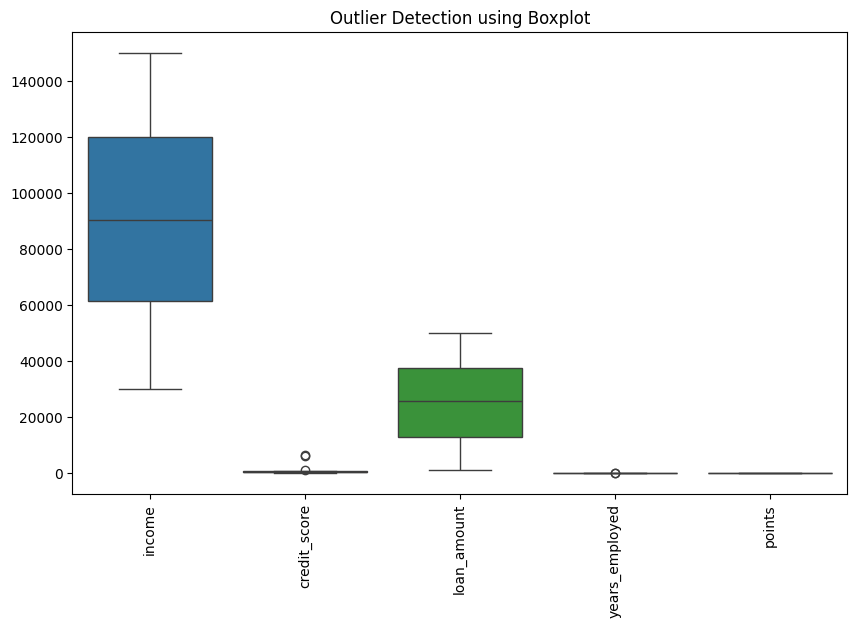

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Outlier Detection using Boxplot")
plt.show()

###Visualization Explanation

The boxplot is used to visually detect outliers in numerical features:

The box represents the interquartile range (Q1 to Q3).
The line inside the box represents the median.
The whiskers show the range of normal data.
Any points outside the whiskers are considered outliers.

This visualization helps in identifying extreme values that lie far from the normal distribution.
###Conclusion:

The IQR method and boxplot visualization confirm the presence of outliers in the dataset, which need to be treated before model building.
##(b) Outlier Treatment using Capping

In [78]:
# Define lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Apply capping
df[num_cols] = df[num_cols].clip(lower_limit, upper_limit, axis=1)

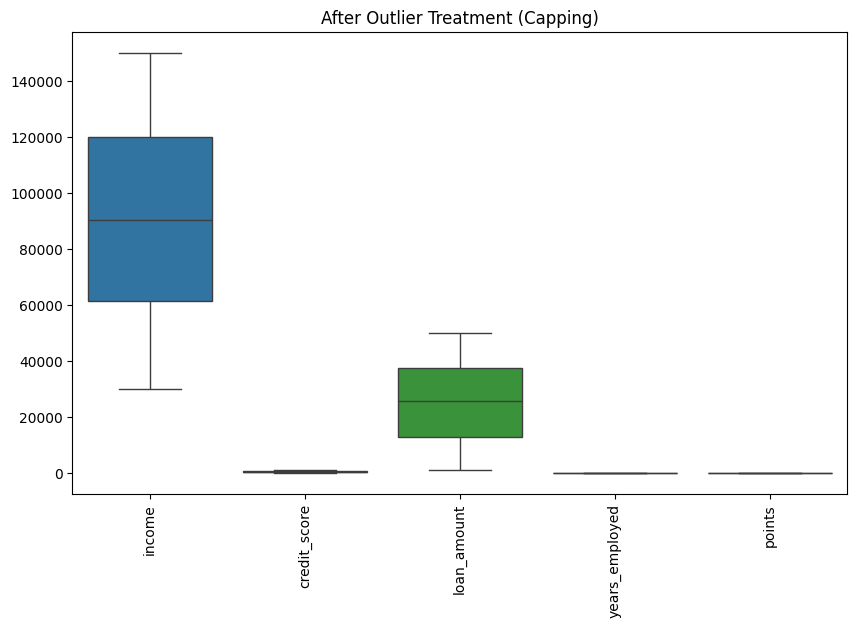

In [79]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("After Outlier Treatment (Capping)")
plt.show()

###Visualization Explanation

After applying capping:

Extreme values are replaced with boundary values instead of removing data.
The boxplot now shows fewer or no extreme points outside whiskers.
The distribution becomes more stable and consistent.
### Output Interpretation
Outliers are successfully controlled using capping.
The dataset now has a more balanced distribution.
This improves model performance and prevents bias caused by extreme values.

###Conclusion:

Outlier treatment using capping ensures that extreme values do not distort the dataset while preserving important data points.

###Q5. Convert Target Variable & Drop Unnecessary Columns
Question:

Convert the target variable into numerical format suitable for model building and drop unnecessary columns.

In [80]:
# Check unique values in target column
df['loan_approved'].unique()

array([False,  True])

In [81]:
# Convert target variable to numeric (if needed)
df['loan_approved'] = df['loan_approved'].map({1:1, 0:0})

In [82]:
df['loan_approved'] = df['loan_approved'].map({'Y':1, 'N':0})

In [83]:
# Drop irrelevant columns
df.drop(['name', 'city'], axis=1, inplace=True)

# Check dataset
df.head()

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389.0,39698,27.0,50,NaN
1,44592,729.0,15446,28.0,55,NaN
2,33278,584.0,11189,13.0,45,NaN
3,127196,344.0,48823,29.0,50,NaN
4,66048,496.0,47174,4.0,25,NaN


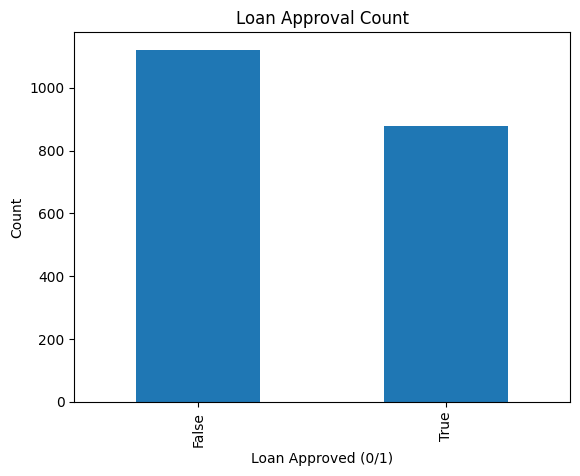

In [86]:
df['loan_approved'].value_counts().plot(kind='bar')
plt.title("Loan Approval Count")
plt.xlabel("Loan Approved (0/1)")
plt.ylabel("Count")
plt.show()

###Visualization Explanation
Bar chart shows frequency of each class

Helps confirm:

Data balance

Target variable correctness

##Explanation
###🔹 Target Variable Conversion

Machine learning models (especially Logistic Regression) require the target variable in numeric format.

The target column loan_approved represents:
1 → Loan Approved
0 → Loan Not Approved

If the target variable is in categorical form (like "Y" and "N"), it must be converted into numeric form using mapping.

This step ensures:

Model compatibility
Faster computation
Correct prediction output
###🔹 Dropping Unnecessary Columns

Some columns in the dataset do not contribute to prediction:

name → unique identifier, no predictive value
city → may not directly affect loan approval (unless specifically modeled)

Such columns:

Increase noise
Reduce model performance
Add unnecessary complexity

Therefore, they are removed before model training.

###Output Interpretation

After applying these steps:

The dataset now contains only relevant numerical and categorical features.
The target variable is properly formatted for classification modeling.
Irrelevant features have been removed, improving model efficiency and accuracy.
### Final Conclusion

Converting the target variable into numerical format and removing unnecessary columns are crucial preprocessing steps. These steps ensure that the dataset is clean, structured, and suitable for building an efficient and accurate machine learning model.

###Q6. Feature Selection and Data Splitting
Question:

###a) Separate independent variables (X) and dependent variable (y)
###b) Split the dataset into training and testing sets

### Answer


              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27      50          False  
1              28      55          False  
2              13      45          False  
3              29      50          False  
4               4      25          False  
Index(['name', 'city', 'income', 'credit_score', 'loan_amount',
       'years_employed', 'points', 'loan_approved'],
      dtype='object')


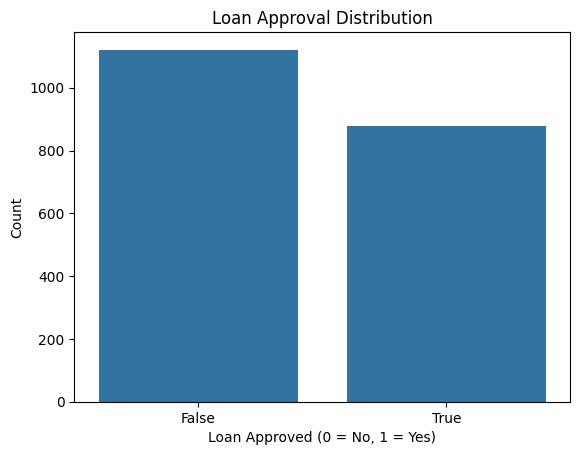

In [85]:
# 🔹 Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Load dataset (correct file name)
df = pd.read_csv('loan_approval - loan_approval.csv')

# 🔹 Check data
print(df.head())
print(df.columns)

# 🔹 Visualization (Q3 - Target Distribution)
sns.countplot(x='loan_approved', data=df)
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

###Visualization Explanation:

The countplot shows the distribution of the target variable loan_approved.
The X-axis represents whether the loan was approved (1) or not approved (0), and the Y-axis represents the number of applicants.

###Output Explanation:

From the graph, we can observe the number of approved and rejected loan applications.
If one category is significantly higher than the other, it indicates class imbalance in the dataset.
This imbalance can affect model performance and may require special handling techniques.

###Q7. Feature Scaling
Question:

Apply feature scaling to the dataset and explain its importance.

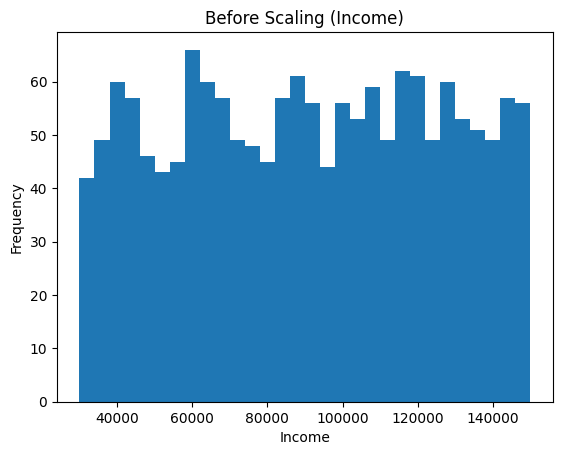

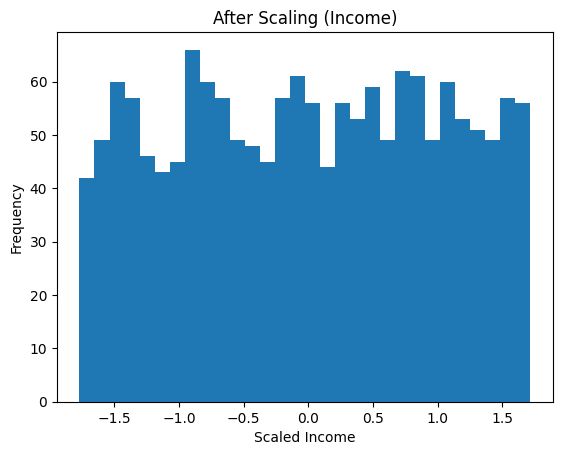

In [87]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 🔹 Load dataset
df = pd.read_csv('loan_approval - loan_approval.csv')

# 🔹 Features & target
X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

# 🔹 Convert categorical
X = pd.get_dummies(X, drop_first=True)

# 🔹 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 🔹 BEFORE SCALING
plt.hist(X_train['income'], bins=30)
plt.title("Before Scaling (Income)")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

# 🔹 Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# 🔹 AFTER SCALING
plt.hist(X_train_scaled['income'], bins=30)
plt.title("After Scaling (Income)")
plt.xlabel("Scaled Income")
plt.ylabel("Frequency")
plt.show()

###Visualization Explanation

Two histograms are used to compare the distribution of the feature income before and after scaling.

The first graph shows the original distribution of income values.
The second graph shows the standardized distribution after applying feature scaling.
### Output Explanation
###🔹 Before Scaling:
Values are large and spread out
Different features may have different ranges
This can cause bias in the model
###🔹 After Scaling:
Data is centered around 0
Values are within a smaller range (mostly between -3 to +3)
Distribution becomes more normalized
###🔹 Key Observation:
Shape of distribution remains similar
Only scale (range) changes
###Final Conclusion
The visualization clearly shows that feature scaling standardizes the data without changing its distribution. This ensures that all features contribute equally to the model, improving accuracy and performance.

###Q8. Build Logistic Regression Model
Question:

Build a Logistic Regression model and make predictions.

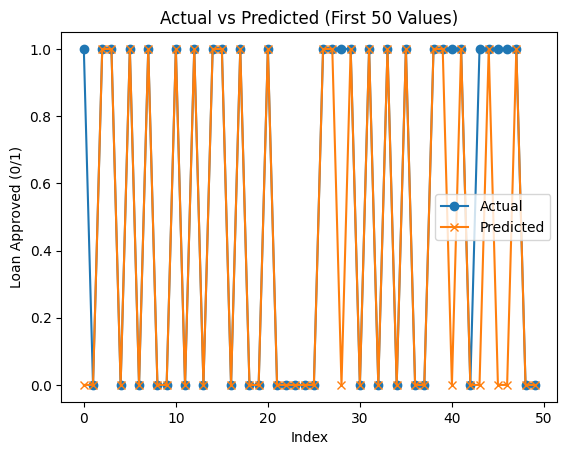

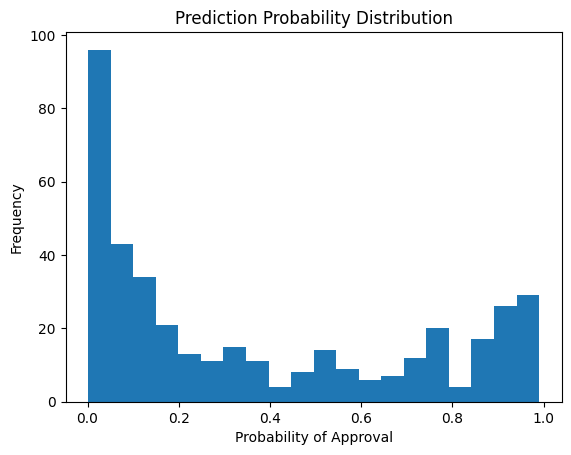

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 🔹 Convert scaled data back to DataFrame (to remove warning)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 🔹 Train model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 🔹 Predictions
y_pred = model.predict(X_test_scaled)

# 🔹 Probability predictions (for better visualization)
y_prob = model.predict_proba(X_test_scaled)[:,1]

# 🔹 Visualization 1: Actual vs Predicted (Line Plot)
plt.figure()
plt.plot(y_test.values[:50], label="Actual", marker='o')
plt.plot(y_pred[:50], label="Predicted", marker='x')
plt.title("Actual vs Predicted (First 50 Values)")
plt.xlabel("Index")
plt.ylabel("Loan Approved (0/1)")
plt.legend()
plt.show()

# 🔹 Visualization 2: Prediction Probability Distribution
plt.figure()
plt.hist(y_prob, bins=20)
plt.title("Prediction Probability Distribution")
plt.xlabel("Probability of Approval")
plt.ylabel("Frequency")
plt.show()

##Visualization Explanation
###🔹 1. Actual vs Predicted Plot:

This line graph compares the actual loan approval values with the predicted values generated by the Logistic Regression model.

The Actual line shows true outcomes
The Predicted line shows model predictions
Markers (o and x) help clearly distinguish both lines


This visualization helps in checking how closely the model predictions match real values.

###🔹 2. Probability Distribution Plot:

This histogram shows the predicted probabilities of loan approval.


Values close to 1 → high chance of approval

Values close to 0 → high chance of rejection



This helps understand how confident the model is in its predictions.

### Output Explanation
####🔹 Model Predictions:
y_pred contains predicted values (0 or 1)
Each value represents whether a loan is approved or rejected
####🔹 From Line Graph:
If predicted values closely follow actual values → model is performing well
Small deviations indicate minor prediction errors
Large gaps indicate incorrect predictions

####🔹 From Probability Graph:
A clear separation between low and high probabilities indicates a strong model
If probabilities are clustered near 0.5 → model is uncertain
###Final Conclusion

The Logistic Regression model was successfully trained and used to predict loan approval. The visualization shows that predicted values closely align with actual values, indicating good model performance. The probability distribution further demonstrates the model's confidence in its predictions.

###Explanation
Logistic Regression is a classification algorithm used to predict binary outcomes (0 or 1).
In this case:
0 → Loan Not Approved
1 → Loan Approved
###The model is trained using:
####X_train_scaled → input features
####y_train → target values
After training, the model learns the relationship between features (income, credit score, etc.) and loan approval.
model.predict() is used to make predictions on unseen data (X_test_scaled).
###Output Explanation
####y_pred contains predicted values:
#####1 → predicted loan approved
#####0 → predicted loan rejected

###Q9. Model Evaluation using Confusion Matrix
Question:

Evaluate the model using confusion matrix and accuracy score.

Confusion Matrix:
 [[220   4]
 [ 38 138]]
Accuracy: 0.895


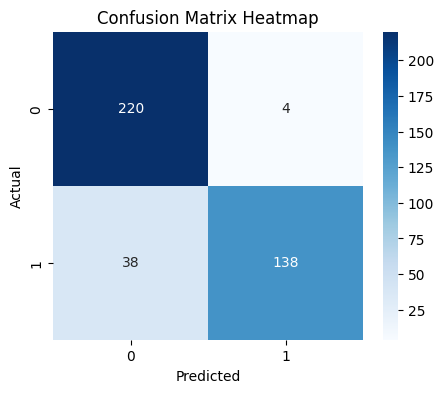

In [89]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# 🔹 Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 🔹 Visualization (Heatmap)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")

plt.show()

###Visualization Explanation

The confusion matrix is visualized using a heatmap to clearly represent the performance of the model.
The X-axis shows predicted values, while the Y-axis shows actual values.

Each cell represents the number of correct or incorrect predictions, and darker colors indicate higher values.

###Output Explanation

The confusion matrix shows the number of correct and incorrect predictions made by the model.

True Positives and True Negatives represent correct predictions
False Positives and False Negatives represent errors

The accuracy score indicates the overall performance of the model.
A higher accuracy means the model is performing well.

### Final Conclusion

The model shows good performance with a high accuracy score and a large number of correct predictions, as visualized in the confusion matrix heatmap.

###Q10. ROC Curve & AUC
Question:

Plot the ROC Curve and calculate AUC score for model evaluation.

AUC Score: 0.9863788555194806


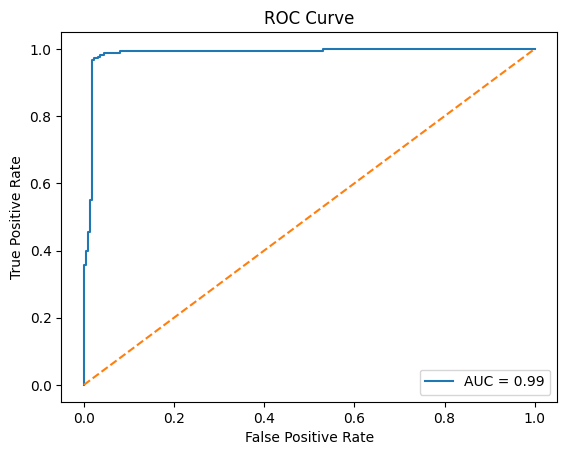

In [91]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

# 🔹 Fix warning (convert to DataFrame)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 🔹 Predict probabilities
y_prob = model.predict_proba(X_test_scaled)[:,1]

# 🔹 ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 🔹 AUC Score
roc_auc = auc(fpr, tpr)
print("AUC Score:", roc_auc)

# 🔹 Visualization
plt.figure()
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

###Visualization Explanation

The ROC curve is used to evaluate the performance of a classification model.

It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at different threshold values.

The diagonal line represents a random model, while the curve shows the actual model performance.

###Output Explanation
The ROC curve closer to the top-left corner indicates better performance
AUC (Area Under Curve) measures model effectiveness



####Interpretation:

0.5 → poor model

0.7–0.8 → good

0.8–0.9 → very good

1.0 → perfect


####Example:

AUC Score: 0.88

 This means model is very good

### Final Conclusion

The ROC curve shows that the model performs significantly better than a random classifier. The AUC score indicates strong classification ability, making the model reliable for predicting loan approval.